In [ ]:
# Get loaddot_env and loging to huggingface
from dotenv import load_dotenv
import os
load_dotenv()
from huggingface_hub import login
# ( token: typing.Optional[str] = Noneadd_to_git_credential: bool = Falseskip_if_logged_in: bool = True )

token = os.getenv("HF_TOKEN")
login(token=token, add_to_git_credential=True, skip_if_logged_in=True)


In [ ]:
model_id ="google/paligemma2-3b-pt-448"

from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration
from PIL import Image
import torch

# Load processor and model
processor = PaliGemmaProcessor.from_pretrained(model_id)
model = model = PaliGemmaForConditionalGeneration.from_pretrained(model_id, device_map="auto", torch_dtype=torch.bfloat16)



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


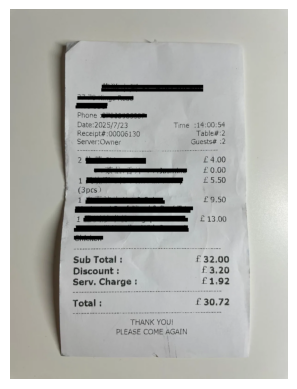

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = '/content/drive/MyDrive/testpaligemma-ios.jpeg'
image = Image.open(image_path).convert("RGB")
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
prompt = "<image>what is the date printed on the ticket?"

inputs = processor(text=prompt, images=image, return_tensors="pt").to(torch.bfloat16).to(model.device)
output = model.generate(**inputs, max_new_tokens=20)

print(processor.decode(output[0], skip_special_tokens=True))

In [ ]:
prompt = "<image>what is the total price on the ticket?"

inputs = processor(text=prompt, images=image, return_tensors="pt").to(torch.bfloat16).to(model.device)
output = model.generate(**inputs, max_new_tokens=20)

print(processor.decode(output[0], skip_special_tokens=True))

In [3]:
import os
import torch
from datasets import load_dataset
from transformers import (
    PaliGemmaForConditionalGeneration,
    PaliGemmaProcessor,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

ds = load_dataset("merve/vqav2-small", split="validation")
split_ds = ds.train_test_split(test_size=0.95)
train_ds = split_ds["test"]

# If possible, switch to a smaller vision resolution model instead of 448.
model_id = "google/paligemma2-3b-pt-448"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,   # T4 usually works more reliably with fp16; see note below
)

model = PaliGemmaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
)

# Freeze non-text parts
for p in model.vision_tower.parameters():
    p.requires_grad = False

for p in model.multi_modal_projector.parameters():
    p.requires_grad = False

# Required prep for k-bit training
model = prepare_model_for_kbit_training(model)

# Saves activation memory
model.gradient_checkpointing_enable()
model.config.use_cache = False

# Smallest practical LoRA setup
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.0,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

processor = PaliGemmaProcessor.from_pretrained(model_id, use_fast=True)

def collate_fn(examples):
    texts = ["<image>answer en " + ex["question"] for ex in examples]
    labels = [ex["multiple_choice_answer"] for ex in examples]
    images = [ex["image"].convert("RGB") for ex in examples]

    batch = processor(
        text=texts,
        images=images,
        suffix=labels,
        return_tensors="pt",
        padding="longest",
    )

    # move only, do not cast everything to bf16/fp16
    return {k: v.to(model.device) for k, v in batch.items()}

args = TrainingArguments(
    output_dir="paligemma2_qlora_t4_minram",
    num_train_epochs=1,                    # start tiny
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,         # keep effective batch without VRAM spike
    remove_unused_columns=False,
    learning_rate=1e-4,                    # common LoRA starting point
    warmup_steps=5,
    logging_steps=10,
    save_strategy="no",                    # saves disk/RAM overhead during testing
    report_to="none",
    dataloader_pin_memory=False,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim="paged_adamw_8bit",              # lower optimizer memory
    fp16=True,                             # for T4, fp16 is usually the safe choice
    bf16=False,
)

trainer = Trainer(
    model=model,
    train_dataset=train_ds,
    data_collator=collate_fn,
    args=args,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 1,296,384 || all params: 3,034,423,536 || trainable%: 0.0427


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
It is strongly recommended to train Gemma2 models with the `eager` attention implementation instead of `sdpa`. Use `eager` with `AutoModelForCausalLM.from_pretrained('<path-to-checkpoint>', attn_implementation='eager')`.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss


KeyboardInterrupt: 

In [ ]:
# import torch
# from transformers import BitsAndBytesConfig, PaliGemmaForConditionalGeneration

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_compute_dtype=torch.float16,   # better choice on T4
# )

# model = PaliGemmaForConditionalGeneration.from_pretrained(
#     "google/paligemma2-3b-pt-448",
#     quantization_config=bnb_config,
#     device_map="auto",
# )